In the 20x20 grid below, four numbers along a diagonal line have been marked in red. 

The product of these numbers is 26x63x78x14=1788696

What is the greatest product of four adjacent numbers in the same direction (up, down, left, right, or diagonally) in the 20x20 grid?

In [32]:
n = '''08 02 22 97 38 15 00 40 00 75 04 05 07 78 52 12 50 77 91 08
49 49 99 40 17 81 18 57 60 87 17 40 98 43 69 48 04 56 62 00
81 49 31 73 55 79 14 29 93 71 40 67 53 88 30 03 49 13 36 65
52 70 95 23 04 60 11 42 69 24 68 56 01 32 56 71 37 02 36 91
22 31 16 71 51 67 63 89 41 92 36 54 22 40 40 28 66 33 13 80
24 47 32 60 99 03 45 02 44 75 33 53 78 36 84 20 35 17 12 50
32 98 81 28 64 23 67 10 26 38 40 67 59 54 70 66 18 38 64 70
67 26 20 68 02 62 12 20 95 63 94 39 63 08 40 91 66 49 94 21
24 55 58 05 66 73 99 26 97 17 78 78 96 83 14 88 34 89 63 72
21 36 23 09 75 00 76 44 20 45 35 14 00 61 33 97 34 31 33 95
78 17 53 28 22 75 31 67 15 94 03 80 04 62 16 14 09 53 56 92
16 39 05 42 96 35 31 47 55 58 88 24 00 17 54 24 36 29 85 57
86 56 00 48 35 71 89 07 05 44 44 37 44 60 21 58 51 54 17 58
19 80 81 68 05 94 47 69 28 73 92 13 86 52 17 77 04 89 55 40
04 52 08 83 97 35 99 16 07 97 57 32 16 26 26 79 33 27 98 66
88 36 68 87 57 62 20 72 03 46 33 67 46 55 12 32 63 93 53 69
04 42 16 73 38 25 39 11 24 94 72 18 08 46 29 32 40 62 76 36
20 69 36 41 72 30 23 88 34 62 99 69 82 67 59 85 74 04 36 16
20 73 35 29 78 31 90 01 74 31 49 71 48 86 81 16 23 57 05 54
01 70 54 71 83 51 54 69 16 92 33 48 61 43 52 01 89 19 67 48'''
matriz = [int(numero) for numero in n.replace('\n', ' ').split(' ')]

48

# Primer intento:

fuerza bruta evitando los ceros cuando son encontrados

In [47]:
import math

def primer_intento():
    resultado = 0
    actual = 0
    for i in range(len(matriz)):
        actual = matriz[i]
        if actual == 0: continue
        linea_actual = i // 20
        h = {i + 1, i + 2, i + 3}
        resultado = resultado if any(fuera_de_rango_o_cero_o_desalineado(j, linea_actual) for j in h) else max(resultado, actual*math.prod(matriz[k] for k in h))
        v = {i + 20, i + 40, i + 60}
        resultado = resultado if any(fuera_de_rango_o_cero(j) for j in v) else max(resultado, actual*math.prod(matriz[k] for k in v))
        d = {i + 21, i + 42, i + 63}
        resultado = resultado if any(fuera_de_rango_o_cero(j) for j in d) else max(resultado, actual*math.prod(matriz[k] for k in d))
        d_i = {i + 19, i + 38, i + 57}
        resultado = resultado if any(fuera_de_rango_o_cero(j) for j in d_i) else max(resultado, actual*math.prod(matriz[k] for k in d_i))
    return resultado

def fuera_de_rango_o_cero(indice):
    return indice < 0 or indice > 399 or matriz[indice] == 0

def fuera_de_rango_o_cero_o_desalineado(indice, linea):
    return fuera_de_rango_o_cero(indice) or (indice//20) != linea

primer_intento()

70600674

# Optimizacion:

claude recomienda trabajar directamente sobre la lista plana con índices 2D explícitos, eliminando los `set`, `math.prod` y la función auxiliar:

In [45]:
def optimizacion():
    resultado = 0
    for r in range(20):
        for c in range(20):
            b = r * 20 + c
            if c <= 16:
                resultado = max(resultado, matriz[b]*matriz[b+1]*matriz[b+2]*matriz[b+3])
            if r <= 16:
                resultado = max(resultado, matriz[b]*matriz[b+20]*matriz[b+40]*matriz[b+60])
            if r <= 16 and c <= 16:
                resultado = max(resultado, matriz[b]*matriz[b+21]*matriz[b+42]*matriz[b+63])
            if r <= 16 and c >= 3:
                resultado = max(resultado, matriz[b]*matriz[b+19]*matriz[b+38]*matriz[b+57])
    return resultado

optimizacion()

70600674

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 70600674
Consistente: True
Repeticiones por corrida: 10
Tiempo promedio:  1.4023 ms
Tiempo mediano:   1.3903 ms
Tiempo minimo:    1.3379 ms
Tiempo stdev:     50.9137 us  (CV: 3.6%)
Memoria promedio: 1.5000 KB
Memoria mediana:  1.5000 KB
Memoria maxima:   1.5000 KB
Asignaciones (mediana): 2

--- Optimizacion ---
Resultado: 70600674
Consistente: True
Repeticiones por corrida: 100
Tiempo promedio:  188.1560 us
Tiempo mediano:   186.7292 us
Tiempo minimo:    185.3463 us
Tiempo stdev:     3.7289 us  (CV: 2.0%)
Memoria promedio: 336.0000 B
Memoria mediana:  336.0000 B
Memoria maxima:   336.0000 B
Asignaciones (mediana): 2

=== Comparacion directa ===
Speedup en tiempo:    7.45x  (gana: Optimizacion)
Ratio de memoria:     4.57x  (gana: Optimizacion)
Ratio asignaciones:   empate (2)


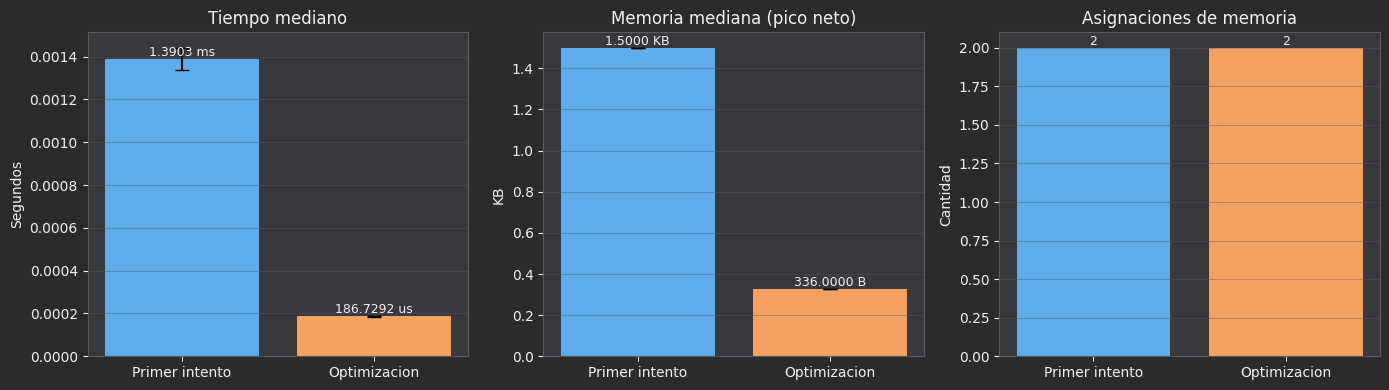

{'Primer intento': {'resultado': 70600674,
  'consistente': True,
  'tiempos': [0.0014968861999999916,
   0.001393301700000027,
   0.0013637589000000006,
   0.0013714500999999935,
   0.0013378614999999705,
   0.0014219248999999933,
   0.0014461266999999723,
   0.0013873817000000343],
  'memorias': [1.5, 1.5, 1.5, 1.5],
  'asignaciones': [2, 2, 2, 2],
  'repeticiones': 10},
 'Optimizacion': {'resultado': 70600674,
  'consistente': True,
  'tiempos': [0.00018730453999999953,
   0.00019184021000000052,
   0.00019567667000000455,
   0.00018541625000000116,
   0.00018550171999999422,
   0.00018534632000000606,
   0.000186153899999999,
   0.000188008669999995],
  'memorias': [0.328125, 0.328125, 0.328125, 0.328125],
  'asignaciones': [2, 2, 2, 2],
  'repeticiones': 100}}

In [48]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)